# 23CSE301 ML Capstone — Review 1 Case Study Template
## EV Charging Stations Dataset

**Review 1 scope:** complete EDA + preprocessing/feature engineering + all 10 regression algorithms + Classification Part A (5 algorithms), following the provided capstone guidelines.

**Dataset:** `EV_Charging_Stations_Feb82024.xlsx` — `Cleaned` sheet.

>
### Regression case study
**Proposed target:** `EV Level2 EVSE Num`

The direct charger-count fields (`EV Level1 EVSE Num`, `EV Level2 EVSE Num`, `EV DC Fast Count`) are excluded from the regression predictors to avoid target leakage.

### Classification case study
**Proposed target:** `Access Code` (`public` / `private`)

Potentially target-defining fields such as `Access Detail Code` are excluded from predictors.

### Required Review 1 algorithms
**Regression (10):** Linear Regression, Ridge, Lasso, ElasticNet, Polynomial Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, SVR, KNN Regressor.

**Classification Part A (5):** Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree Classifier, SVC.

**Mandatory regression metrics:** R², RMSE, MAE; 5-fold CV R² for the two best models.

**Mandatory classification metrics:** Accuracy, Precision, weighted Recall, weighted F1, Confusion Matrix, ROC-AUC (OvR for multiclass).


## 0. Imports, reproducibility, and configuration
Keep all configuration in one place so the notebook is easy to update before review.

In [6]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

# Regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

RANDOM_STATE = 42
TEST_SIZE = 0.20

DATA_PATH = "EV_Charging_Stations_Feb82024.xlsx"
SHEET_NAME = "Cleaned"

REG_TARGET = "EV Level2 EVSE Num"
CLF_TARGET = "Access Code"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


In [7]:
# Load dataset
df = pd.read_excel(DATA_PATH, sheet_name="Raw")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (65134, 74)


,Fuel Type Code,Station Name,Street Address,Intersection Directions,City,State,ZIP,Plus4,Station Phone,Status Code,Expected Date,Groups With Access Code,Access Days Time,Cards Accepted,BD Blends,NG Fill Type Code,NG PSI,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,EV Other Info,EV Network,EV Network Web,Geocode Status,Latitude,Longitude,Date Last Confirmed,ID,Updated At,Owner Type Code,Federal Agency ID,Federal Agency Name,Open Date,Hydrogen Status Link,NG Vehicle Class,LPG Primary,E85 Blender Pump,EV Connector Types,Country,Intersection Directions (French),Access Days Time (French),BD Blends (French),Groups With Access Code (French),Hydrogen Is Retail,Access Code,Access Detail Code,Federal Agency Code,Facility Type,CNG Dispenser Num,CNG On-Site Renewable Source,CNG Total Compression Capacity,CNG Storage Capacity,LNG On-Site Renewable Source,E85 Other Ethanol Blends,EV Pricing,EV Pricing (French),LPG Nozzle Types,Hydrogen Pressures,Hydrogen Standards,CNG Fill Type Code,CNG PSI,CNG Vehicle Class,LNG Vehicle Class,EV On-Site Renewable Source,Restricted Access,RD Blends,RD Blends (French),RD Blended with Biodiesel,RD Maximum Biodiesel Level,NPS Unit Name,CNG Station Sells Renewable Natural Gas,LNG Station Sells Renewable Natural Gas,Maximum Vehicle Class,EV Workplace Charging
0,ELEC,LADWP - Truesdale Center,11797 Truesdale St,NaN,Sun Valley,CA,91352,NaN,NaN,E,NaN,Private,Fleet use only,NaN,NaN,NaN,NaN,NaN,57.0,2.0,NaN,SHELL_RECHARGE,https://shellrecharge.com/en-us/solutions,GPS,34.248319,-118.387971,2023-09-14,1517,2024-01-31 22:07:01 UTC,LG,NaN,NaN,1999-10-15,NaN,NaN,NaN,NaN,CHADEMO J1772 J1772COMBO,US,NaN,NaN,NaN,Privé,NaN,private,NaN,NaN,UTILITY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,ELEC,Los Angeles Convention Center,1201 S Figueroa St,West hall and South hall,Los Angeles,CA,90015,NaN,213-741-1151,E,NaN,Public,5:30am-9pm; pay lot,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,Non-Networked,NaN,GPS,34.040539,-118.271387,2023-01-10,1523,2023-02-14 15:54:11 UTC,P,NaN,NaN,1995-08-30,NaN,NaN,NaN,NaN,J1772,US,NaN,NaN,NaN,Public,NaN,public,NaN,NaN,PARKING_GARAGE,NaN,NaN,NaN,NaN,NaN,NaN,Free; parking fee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,0.0
2,ELEC,LADWP - John Ferraro Building,111 N Hope St,Across Hope,Los Angeles,CA,90012,NaN,NaN,E,NaN,Private,For fleet and employee use only,NaN,NaN,NaN,NaN,NaN,338.0,12.0,NaN,Non-Networked,NaN,GPS,34.059133,-118.248589,2023-09-14,1525,2024-01-31 22:07:01 UTC,LG,NaN,NaN,1999-10-15,NaN,NaN,NaN,NaN,CHADEMO J1772 J1772COMBO,US,NaN,NaN,NaN,Privé,NaN,private,NaN,NaN,UTILITY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LD,1.0
3,ELEC,LADWP - Haynes Power Plant,6801 E 2nd St,NaN,Long Beach,CA,90803,NaN,NaN,E,NaN,Private,Fleet use only,NaN,NaN,NaN,NaN,NaN,19.0,1.0,NaN,Non-Networked,NaN,GPS,33.759802,-118.096665,2024-01-09,1531,2024-01-31 22:07:01 UTC,LG,NaN,NaN,2018-05-01,NaN,NaN,NaN,NaN,CHADEMO J1772 J1772COMBO,US,NaN,NaN,NaN,Privé,NaN,private,NaN,NaN,UTILITY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,ELEC,LADWP - Harbor Generating Station,161 N Island Ave,At B St,Wilmington,CA,90744,NaN,NaN,E,NaN,Private,Fleet use only,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,Non-Networked,NaN,200-8,33.770508,-118.265628,2024-01-09,1552,2024-01-31 22:07:01 UTC,LG,NaN,NaN,1999-10-15,NaN,NaN,NaN,NaN,J1772,US,NaN,NaN,NaN,Privé,NaN,private,NaN,NaN,UTILITY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


## 1. Problem statement and dataset understanding

### Regression problem statement
> Predict the number of **Level 2 EV charging stations/EVSE units** at an EV charging location using non-target station attributes, while avoiding direct charger-count leakage.

### Classification problem statement
> Predict whether an EV charging location is **public or private** using station attributes that do not directly encode the target.

### Dataset description
Fill this section with the team's final, original description after inspecting the data.

**Team notes:**
- Source: Alternative Fuels Data Center (dataset source recorded in the workbook).
- Rows / columns: report from the audit below.
- Target variable: justify why it is meaningful.
- Predictor variables: explain why selected fields may be useful.


In [8]:
# Dataset source recorded in the workbook
source_df = pd.read_excel(DATA_PATH, sheet_name="Source")
display(source_df)


,Source,https://afdc.energy.gov/stations/#/analyze
0,"Information pulled on February 8, 2024",NaN


## 2. Dataset loading and audit
This section directly covers the Review 1 rubric requirement for shape, dtypes, missing-value counts, and target/class distribution.

In [9]:
# Shape, dtypes, and missing values
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_count").head(30))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nRegression target distribution:")
display(df[REG_TARGET].describe())

print("\nClassification target distribution:")
display(df[CLF_TARGET].value_counts(dropna=False).to_frame("count"))


Shape: (65134, 74)

Data types:


,dtype
Fuel Type Code,object
Station Name,object
Street Address,object
Intersection Directions,object
City,object
State,object
ZIP,object
Plus4,float64
Station Phone,object
Status Code,object



Missing values:


,missing_count
CNG PSI,65134
CNG Total Compression Capacity,65134
E85 Blender Pump,65134
LPG Primary,65134
NG Vehicle Class,65134
Hydrogen Status Link,65134
BD Blends (French),65134
CNG Vehicle Class,65134
Hydrogen Is Retail,65134
RD Blends,65134



Duplicate rows: 0

Regression target distribution:


count    56677.000000
mean         2.420382
std          3.273703
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max        338.000000
Name: EV Level2 EVSE Num, dtype: float64


Classification target distribution:


,count
Access Code,
public,61308
private,3826


## 3. EDA
**Required by the rubric:** feature distributions, correlation heatmap, target distribution, and at least two scatter plots showing feature-target relationships.

Add a short Markdown observation **after every major visualization**. Do not copy generic observations; write what the actual plot shows.

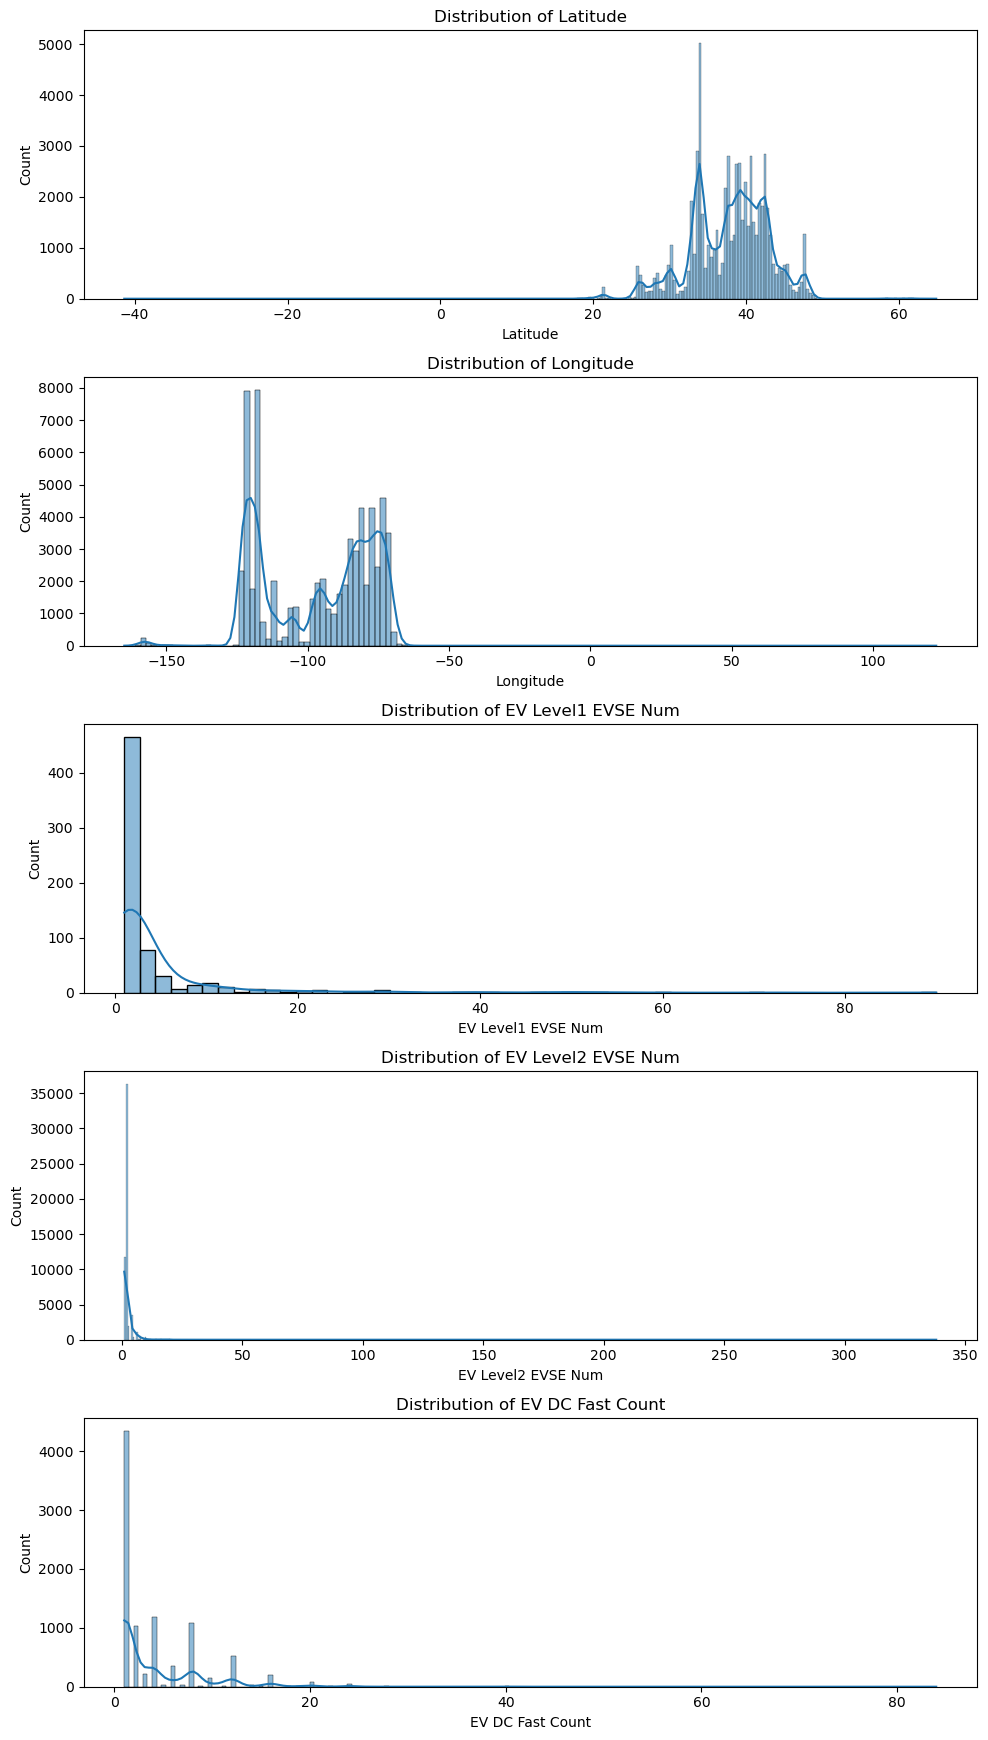

In [10]:
# 3.1 Numeric feature distributions
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Keep the core numeric variables readable in the template.
eda_numeric = [
    c for c in [
        "Latitude", "Longitude",
        "EV Level1 EVSE Num", "EV Level2 EVSE Num", "EV DC Fast Count"
    ] if c in df.columns
]

fig, axes = plt.subplots(len(eda_numeric), 1, figsize=(10, 3.5 * len(eda_numeric)))
if len(eda_numeric) == 1:
    axes = [axes]

for ax, col in zip(axes, eda_numeric):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


**EDA observation — distributions:**  
_Write 2–4 sentences describing skewness, concentration, unusual values, and missingness visible in the plots._

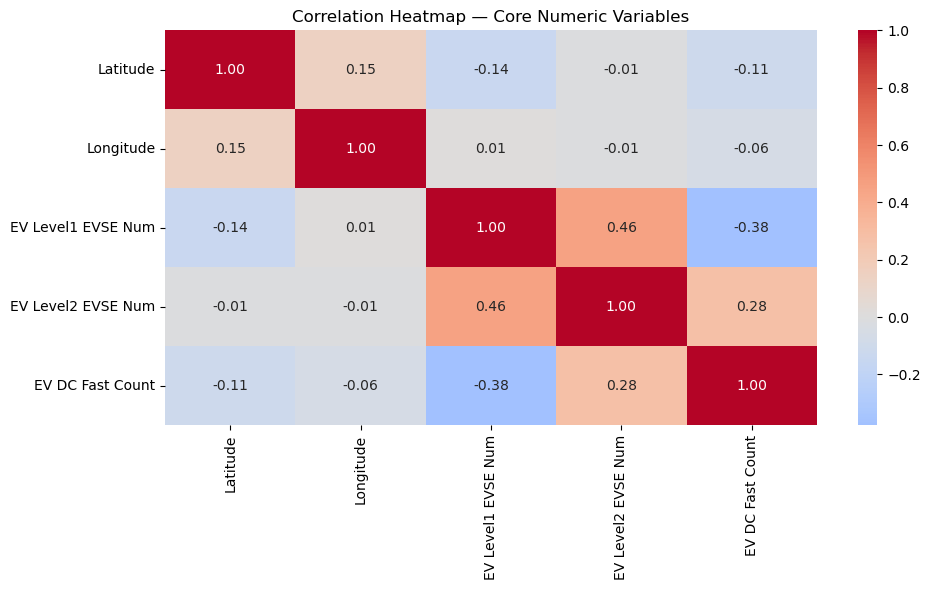

In [11]:
# 3.2 Correlation heatmap
corr_cols = [
    c for c in [
        "Latitude", "Longitude",
        "EV Level1 EVSE Num", "EV Level2 EVSE Num", "EV DC Fast Count"
    ] if c in df.columns
]

plt.figure(figsize=(10, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Core Numeric Variables")
plt.tight_layout()
plt.show()


**EDA observation — correlation:**  
_Explain the strongest positive/negative relationships and identify whether any direct target leakage risk is visible._

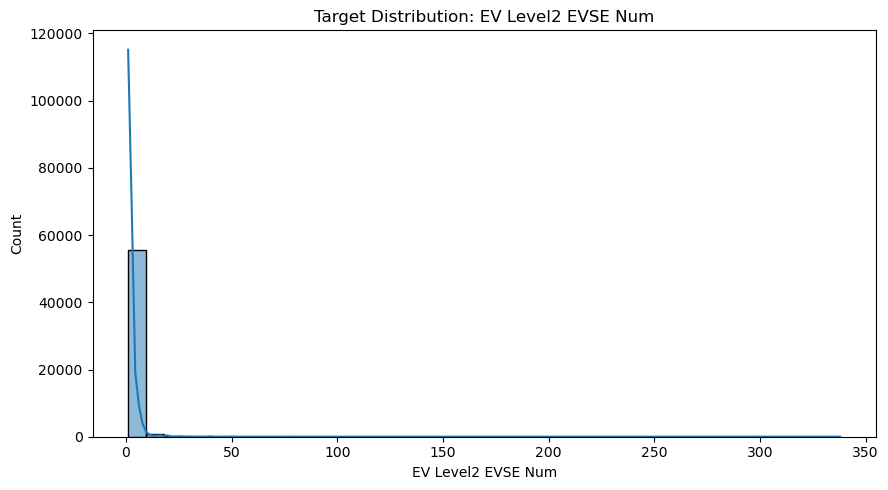

In [12]:
# 3.3 Regression target distribution
plt.figure(figsize=(9, 5))
sns.histplot(df[REG_TARGET].dropna(), bins=40, kde=True)
plt.title(f"Target Distribution: {REG_TARGET}")
plt.xlabel(REG_TARGET)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**EDA observation — regression target:**  
_Comment on the target's skewness, concentration, outliers, and whether a transformation might be worth testing._

In [ ]:
# 3.4 Scatter plot 1 — latitude vs target
plot_df = df[[REG_TARGET, "Latitude"]].dropna()
plt.figure(figsize=(9, 5))
sns.scatterplot(data=plot_df, x="Latitude", y=REG_TARGET, alpha=0.35)
plt.title(f"Latitude vs {REG_TARGET}")
plt.xlabel("Latitude")
plt.ylabel(REG_TARGET)
plt.tight_layout()
plt.show()


**EDA observation — scatter 1:**  
_Write the specific relationship (or lack of relationship) visible in the plot._

In [ ]:
# 3.5 Scatter plot 2 — longitude vs target
plot_df = df[[REG_TARGET, "Longitude"]].dropna()
plt.figure(figsize=(9, 5))
sns.scatterplot(data=plot_df, x="Longitude", y=REG_TARGET, alpha=0.35)
plt.title(f"Longitude vs {REG_TARGET}")
plt.xlabel("Longitude")
plt.ylabel(REG_TARGET)
plt.tight_layout()
plt.show()


**EDA observation — scatter 2:**  
_Write the specific relationship (or lack of relationship) visible in the plot._

In [ ]:
# 3.6 Categorical summaries
for col in ["State", "EV Network", "Facility Type", "Access Code"]:
    if col in df.columns:
        print(f"\nTop categories — {col}")
        display(df[col].value_counts(dropna=False).head(15).to_frame("count"))


**EDA observation — categorical variables:**  
_Explain class/category imbalance and any categories that may need grouping or careful encoding._

## 4. Data cleaning and feature engineering

### Regression leakage control
The regression predictors must **not** contain the target or the other direct charger-count columns.

### Engineered features in this template
- `Open Year`
- `Station Age`
- `Num Connector Types`
- `Is Networked`
- `Has Pricing`
- `Has Workplace Charging`
- `Is Public Access` (for regression only; target is different)

Explain and justify at least one engineered feature in your own words in the final notebook.

In [14]:
# Work on a copy
data = df.copy()

# Dates
if "Open Date" in data.columns:
    data["Open Date"] = pd.to_datetime(data["Open Date"], errors="coerce")
    data["Open Year"] = data["Open Date"].dt.year
    # The dataset snapshot is from February 8, 2024.
    data["Station Age"] = 2024 - data["Open Year"]

# Connector count
if "EV Connector Types" in data.columns:
    data["Num Connector Types"] = (
        data["EV Connector Types"]
        .fillna("")
        .astype(str)
        .str.strip()
        .apply(lambda x: 0 if x == "" else len(set(x.split())))
    )

# Network flag
if "EV Network" in data.columns:
    data["Is Networked"] = (
        data["EV Network"].fillna("Non-Networked").astype(str).str.lower() != "non-networked"
    ).astype(int)

# Pricing flag
if "EV Pricing" in data.columns:
    data["Has Pricing"] = data["EV Pricing"].notna().astype(int)

# Workplace charging flag
if "EV Workplace Charging" in data.columns:
    data["Has Workplace Charging"] = (
        pd.to_numeric(data["EV Workplace Charging"], errors="coerce").fillna(0) > 0
    ).astype(int)

# Public/private flag for regression only
if "Access Code" in data.columns:
    data["Is Public Access"] = (
        data["Access Code"].fillna("").astype(str).str.lower().eq("public")
    ).astype(int)

# Remove exact duplicate rows
before = len(data)
data = data.drop_duplicates().copy()
print("Duplicates removed:", before - len(data))
print("Shape after cleaning:", data.shape)


Duplicates removed: 0
Shape after cleaning: (65134, 81)


**Feature-engineering justification:**  
_Write why at least one engineered feature should help the model. Link the justification to the charging-station domain._

### Outlier handling note
Potential numeric outliers are counted using the training split and then capped using training-derived IQR limits. This keeps the comparison consistent across all regression models and avoids learning caps from the test set.

## 5. Regression dataset and common preprocessing

All ten regression algorithms use the **same train/test split** and the **same processed feature set** so that comparisons are fair.

To keep Polynomial Regression computationally practical, the common regression feature set is intentionally compact and numeric/boolean. The target and all direct charger-count fields are excluded.

In [16]:
# Select regression modeling columns
reg_features = [
    c for c in [
        "Latitude", "Longitude", "Open Year", "Station Age",
        "Num Connector Types", "Is Networked", "Has Pricing",
        "Has Workplace Charging", "Is Public Access"
    ] if c in data.columns
]

reg_df = data[reg_features + [REG_TARGET]].copy()
reg_df = reg_df.dropna(subset=[REG_TARGET]).copy()

X_reg = reg_df[reg_features]
y_reg = reg_df[REG_TARGET]


X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Outlier check + train-only IQR capping.
# Caps are learned from the training split only, avoiding data leakage.
def fit_iqr_caps(X_train, columns, multiplier=1.5):
    caps = {}
    for col in columns:
        s = pd.to_numeric(X_train[col], errors="coerce")
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        caps[col] = (q1 - multiplier * iqr, q3 + multiplier * iqr)
    return caps

def apply_iqr_caps(X, caps):
    out = X.copy()
    for col, (low, high) in caps.items():
        out[col] = pd.to_numeric(out[col], errors="coerce").clip(lower=low, upper=high)
    return out

reg_numeric_for_outliers = [
    c for c in reg_features
    if pd.api.types.is_numeric_dtype(X_reg_train[c])
]

# Report the amount of potential outliers in the training set.
outlier_report = []
for col in reg_numeric_for_outliers:
    s = pd.to_numeric(X_reg_train[col], errors="coerce")
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((s < low) | (s > high)).sum()
    outlier_report.append({"Feature": col, "Potential outliers": int(count)})

display(pd.DataFrame(outlier_report))

REGRESSION_OUTLIER_CAPPING = True
if REGRESSION_OUTLIER_CAPPING:
    reg_caps = fit_iqr_caps(X_reg_train, reg_numeric_for_outliers)
    X_reg_train = apply_iqr_caps(X_reg_train, reg_caps)
    X_reg_test = apply_iqr_caps(X_reg_test, reg_caps)

reg_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Regression features:", reg_features)
print("Regression train shape:", X_reg_train.shape)
print("Regression test shape:", X_reg_test.shape)


,Feature,Potential outliers
0,Latitude,334
1,Longitude,5
2,Open Year,3171
3,Station Age,3171
4,Num Connector Types,3061
5,Is Networked,6743
6,Has Pricing,9852
7,Has Workplace Charging,1075
8,Is Public Access,2697


Regression features: ['Latitude', 'Longitude', 'Open Year', 'Station Age', 'Num Connector Types', 'Is Networked', 'Has Pricing', 'Has Workplace Charging', 'Is Public Access']
Regression train shape: (45341, 9)
Regression test shape: (11336, 9)


## 6. Regression — Model 1: Linear Regression

**Requirement:** Baseline; interpret coefficients.

**Your analysis:** explain baseline performance and which engineered/numeric variables have the largest positive/negative coefficients.

In [ ]:
# MODEL 1 — Linear Regression
linear_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", LinearRegression())
])

linear_reg.fit(X_reg_train, y_reg_train)
pred_linear = linear_reg.predict(X_reg_test)

results_reg = []
def add_reg_result(name, y_true, y_pred):
    results_reg.append({
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAE": mean_absolute_error(y_true, y_pred)
    })

add_reg_result("Linear Regression", y_reg_test, pred_linear)
results_reg[-1]


**Model 1 observation:**  
_Record the actual result and interpret coefficient direction/magnitude after examining the fitted model._

## 7. Regression — Model 2: Ridge Regression

**Requirement:** L2 regularisation; tune `alpha`.

In [ ]:
# MODEL 2 — Ridge Regression
ridge_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_reg.fit(X_reg_train, y_reg_train)
pred_ridge = ridge_reg.predict(X_reg_test)
add_reg_result("Ridge Regression", y_reg_test, pred_ridge)
results_reg[-1]


**Model 2 observation:**  
_Explain what regularisation does and whether Ridge improves on the baseline in this dataset._

## 8. Regression — Model 3: Lasso Regression

**Requirement:** L1 regularisation; observe feature sparsity.

In [ ]:
# MODEL 3 — Lasso Regression
lasso_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", Lasso(alpha=0.01, max_iter=10000))
])

lasso_reg.fit(X_reg_train, y_reg_train)
pred_lasso = lasso_reg.predict(X_reg_test)
add_reg_result("Lasso Regression", y_reg_test, pred_lasso)
results_reg[-1]


**Model 3 observation:**  
_Comment on whether Lasso drives any coefficients close to/at zero and whether that helps or hurts performance._

## 9. Regression — Model 4: ElasticNet Regression

**Requirement:** Combined L1 + L2 regularisation; tune `l1_ratio`.

In [ ]:
# MODEL 4 — ElasticNet Regression
elastic_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000, random_state=RANDOM_STATE))
])

elastic_reg.fit(X_reg_train, y_reg_train)
pred_elastic = elastic_reg.predict(X_reg_test)
add_reg_result("ElasticNet Regression", y_reg_test, pred_elastic)
results_reg[-1]


**Model 4 observation:**  
_Explain the role of both L1 and L2 penalties and what the result says about this dataset._

## 10. Regression — Model 5: Polynomial Regression

**Requirement:** `PolynomialFeatures` + Linear Regression; compare degrees.

In [ ]:
# MODEL 5 — Polynomial Regression
poly_reg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

poly_reg.fit(X_reg_train, y_reg_train)
pred_poly = poly_reg.predict(X_reg_test)
add_reg_result("Polynomial Regression (degree=2)", y_reg_test, pred_poly)
results_reg[-1]


**Model 5 observation:**  
_Compare degree 2 against linear regression. Discuss non-linearity, feature interactions, and any evidence of overfitting._

## 11. Regression — Model 6: Decision Tree Regressor

**Requirement:** Tune `max_depth`; show feature importance.

In [ ]:
# MODEL 6 — Decision Tree Regressor
tree_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE))
])

tree_reg.fit(X_reg_train, y_reg_train)
pred_tree = tree_reg.predict(X_reg_test)
add_reg_result("Decision Tree Regressor", y_reg_test, pred_tree)
results_reg[-1]


**Model 6 observation:**  
_Discuss depth, interpretability, and whether the model appears to capture non-linear structure._

## 12. Regression — Model 7: Random Forest Regressor

**Requirement:** Ensemble baseline; tune `n_estimators`.

In [ ]:
# MODEL 7 — Random Forest Regressor
rf_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

rf_reg.fit(X_reg_train, y_reg_train)
pred_rf = rf_reg.predict(X_reg_test)
add_reg_result("Random Forest Regressor", y_reg_test, pred_rf)
results_reg[-1]


**Model 7 observation:**  
_Explain why an ensemble may outperform a single tree and discuss the observed performance._

## 13. Regression — Model 8: Gradient Boosting Regressor

**Requirement:** Tune `learning_rate`.

In [ ]:
# MODEL 8 — Gradient Boosting Regressor
gbr_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=RANDOM_STATE
    ))
])

gbr_reg.fit(X_reg_train, y_reg_train)
pred_gbr = gbr_reg.predict(X_reg_test)
add_reg_result("Gradient Boosting Regressor", y_reg_test, pred_gbr)
results_reg[-1]


**Model 8 observation:**  
_Explain boosting at a high level and discuss whether gradual learning improves error compared with bagging/tree baselines._

## 14. Regression — Model 9: Support Vector Regressor (SVR)

**Requirement:** Scale features first; tune `C` and `kernel`.

In [ ]:
# MODEL 9 — Support Vector Regressor
svr_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", SVR(C=10, kernel="rbf", epsilon=0.1))
])

svr_reg.fit(X_reg_train, y_reg_train)
pred_svr = svr_reg.predict(X_reg_test)
add_reg_result("Support Vector Regressor", y_reg_test, pred_svr)
results_reg[-1]


**Model 9 observation:**  
_Explain why scaling matters for SVR and discuss the effect of the selected kernel/C conceptually._

## 15. Regression — Model 10: K-Nearest Neighbors Regressor

**Requirement:** Tune `k`; discuss impact of scaling.

In [ ]:
# MODEL 10 — KNN Regressor
knn_reg = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=7, weights="distance"))
])

knn_reg.fit(X_reg_train, y_reg_train)
pred_knn = knn_reg.predict(X_reg_test)
add_reg_result("K-Nearest Neighbors Regressor", y_reg_test, pred_knn)
results_reg[-1]


**Model 10 observation:**  
_Explain why scaling matters for distance-based methods and discuss the effect of k._

## 16. Regression — consolidated comparison

The guidelines require one summary table for all ten models, ranked by R².

In [ ]:
reg_results_df = pd.DataFrame(results_reg).sort_values("R2", ascending=False).reset_index(drop=True)
display(reg_results_df)

best_reg_models = reg_results_df.head(2)["Model"].tolist()
print("Top 2 regression models:", best_reg_models)


## 17. Regression — Hyperparameter tuning

The rubric requires GridSearchCV or RandomizedSearchCV on at least two models. The cells below tune **Random Forest** and **SVR**. Use the actual final tuned values in the report.

In [ ]:
# TUNING 1 — Random Forest
rf_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20]
}

rf_search = GridSearchCV(
    rf_reg, rf_grid, cv=3, scoring="r2",
    n_jobs=-1, verbose=1
)
rf_search.fit(X_reg_train, y_reg_train)

print("Best RF params:", rf_search.best_params_)
rf_tuned_pred = rf_search.predict(X_reg_test)
rf_tuned_r2 = r2_score(y_reg_test, rf_tuned_pred)
print("Tuned RF R2:", rf_tuned_r2)


**Tuning observation — Random Forest:**  
_Report the best parameters and the improvement (if any) over the untuned Random Forest._

In [ ]:
# TUNING 2 — SVR
svr_grid = {
    "model__C": [1, 10, 50],
    "model__kernel": ["linear", "rbf"]
}

svr_search = GridSearchCV(
    svr_reg, svr_grid, cv=3, scoring="r2",
    n_jobs=-1, verbose=1
)
svr_search.fit(X_reg_train, y_reg_train)

print("Best SVR params:", svr_search.best_params_)
svr_tuned_pred = svr_search.predict(X_reg_test)
svr_tuned_r2 = r2_score(y_reg_test, svr_tuned_pred)
print("Tuned SVR R2:", svr_tuned_r2)


**Tuning observation — SVR:**  
_Report the best parameters and improvement compared with the untuned SVR._

## 18. Regression — 5-fold cross-validation for the two best models

The guideline specifically requires **5-fold cross-validated R² for the two best-performing models**.

In [ ]:
# Map model names to trained pipelines
reg_model_map = {
    "Linear Regression": linear_reg,
    "Ridge Regression": ridge_reg,
    "Lasso Regression": lasso_reg,
    "ElasticNet Regression": elastic_reg,
    "Polynomial Regression (degree=2)": poly_reg,
    "Decision Tree Regressor": tree_reg,
    "Random Forest Regressor": rf_reg,
    "Gradient Boosting Regressor": gbr_reg,
    "Support Vector Regressor": svr_reg,
    "K-Nearest Neighbors Regressor": knn_reg,
}

cv_rows = []
for model_name in best_reg_models:
    model = reg_model_map[model_name]
    scores = cross_val_score(model, X_reg, y_reg, cv=5, scoring="r2", n_jobs=-1)
    cv_rows.append({
        "Model": model_name,
        "CV R2 Mean": scores.mean(),
        "CV R2 Std": scores.std()
    })

cv_reg_df = pd.DataFrame(cv_rows)
display(cv_reg_df)


## 19. Regression — required visualisations

Rubric requirement: residual plot, predicted-vs-actual plot for the best model, and feature importance for at least one tree-based model.

In [ ]:
# Select best original (untuned) model by test R2
best_model_name = reg_results_df.iloc[0]["Model"]
best_predictions = {
    "Linear Regression": pred_linear,
    "Ridge Regression": pred_ridge,
    "Lasso Regression": pred_lasso,
    "ElasticNet Regression": pred_elastic,
    "Polynomial Regression (degree=2)": pred_poly,
    "Decision Tree Regressor": pred_tree,
    "Random Forest Regressor": pred_rf,
    "Gradient Boosting Regressor": pred_gbr,
    "Support Vector Regressor": pred_svr,
    "K-Nearest Neighbors Regressor": pred_knn,
}
best_pred = best_predictions[best_model_name]

# Predicted vs actual
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_reg_test, y=best_pred, alpha=0.5)
mn = min(y_reg_test.min(), best_pred.min())
mx = max(y_reg_test.max(), best_pred.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_reg_test - best_pred
plt.figure(figsize=(9, 5))
sns.scatterplot(x=best_pred, y=residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()


**Required visualisation observations:**  
1. _Predicted-vs-actual: describe closeness to the diagonal and systematic deviations._  
2. _Residuals: discuss spread, outliers, and whether residual variance looks constant._

In [ ]:
# Feature importance — tree-based model
# Use the fitted Random Forest as the required tree-based example.
rf_model = rf_reg.named_steps["model"]
rf_importances = pd.Series(rf_model.feature_importances_, index=reg_features).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=rf_importances.values, y=rf_importances.index)
plt.title("Random Forest Regressor — Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(rf_importances.to_frame("importance"))


**Feature-importance observation:**  
_Explain which features matter most for the selected tree model and whether that is consistent with domain expectations._

# 20. Classification Part A

The Review 1 rubric requires the five Part-A classifiers below.

**Target:** `Access Code`

We use non-target-defining station features and a common stratified 80/20 train/test split.

In [17]:
# Prepare classification data
clf_features = [
    c for c in [
        "Latitude", "Longitude", "Open Year", "Station Age",
        "Num Connector Types", "Is Networked", "Has Pricing",
        "Has Workplace Charging", "State", "Facility Type", "EV Network",
        "EV Connector Types"
    ] if c in data.columns
]

clf_df = data[clf_features + [CLF_TARGET]].copy()
clf_df = clf_df.dropna(subset=[CLF_TARGET]).copy()

X_clf = clf_df[clf_features]
y_clf = clf_df[CLF_TARGET].astype(str)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

# Outlier check for numeric classification predictors.
clf_numeric = [c for c in clf_features if X_clf[c].dtype != "object"]
clf_categorical = [c for c in clf_features if X_clf[c].dtype == "object"]

clf_outlier_report = []
for col in clf_numeric:
    s = pd.to_numeric(X_clf_train[col], errors="coerce")
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((s < low) | (s > high)).sum()
    clf_outlier_report.append({"Feature": col, "Potential outliers": int(count)})

display(pd.DataFrame(clf_outlier_report))

# Reuse train-only IQR capping for numeric predictors.
clf_caps = fit_iqr_caps(X_clf_train, clf_numeric)
X_clf_train = apply_iqr_caps(X_clf_train, clf_caps)
X_clf_test = apply_iqr_caps(X_clf_test, clf_caps)

clf_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), clf_numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), clf_categorical)
])

print("Classification features:", clf_features)
print("Numeric:", clf_numeric)
print("Categorical:", clf_categorical)
print("Class distribution:")
display(y_clf.value_counts(normalize=False).to_frame("count"))


,Feature,Potential outliers
0,Latitude,374
1,Longitude,6
2,Open Year,3334
3,Station Age,3334
4,Num Connector Types,6580
5,Is Networked,7392
6,Has Pricing,10402
7,Has Workplace Charging,1121


Classification features: ['Latitude', 'Longitude', 'Open Year', 'Station Age', 'Num Connector Types', 'Is Networked', 'Has Pricing', 'Has Workplace Charging', 'State', 'Facility Type', 'EV Network', 'EV Connector Types']
Numeric: ['Latitude', 'Longitude', 'Open Year', 'Station Age', 'Num Connector Types', 'Is Networked', 'Has Pricing', 'Has Workplace Charging']
Categorical: ['State', 'Facility Type', 'EV Network', 'EV Connector Types']
Class distribution:


,count
Access Code,
public,61308
private,3826


## 21. Classification — Model 1: Logistic Regression

**Requirement:** baseline classifier; interpret coefficients/odds.

In [18]:
clf_results = []

def add_clf_result(name, y_true, y_pred, y_score, labels):
    clf_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score, multi_class="ovr", labels=labels) 
        if len(labels) > 2 else roc_auc_score(LabelEncoder().fit_transform(y_true), y_score[:, 1] 
                                              if getattr(y_score, "ndim", 1) == 2 else y_score)
    })

log_clf = Pipeline([
    ("preprocessor", clf_preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

log_clf.fit(X_clf_train, y_clf_train)
pred_log = log_clf.predict(X_clf_test)
score_log = log_clf.predict_proba(X_clf_test)
labels_clf = sorted(y_clf.unique())

add_clf_result("Logistic Regression", y_clf_test, pred_log, score_log, labels_clf)
clf_results[-1]

{'Model': 'Logistic Regression',
 'Accuracy': 0.965226068933753,
 'Precision': 0.9630755915815316,
 'Recall': 0.965226068933753,
 'F1': 0.9638436592644666,
 'ROC_AUC': 0.9795497647762416}

**Model 1 observation:**  
_Interpret the baseline performance and, where appropriate, discuss coefficient direction/odds after extracting coefficients._

## 22. Classification — Model 2: K-Nearest Neighbors

**Requirement:** tune `k`; discuss distance metrics.

In [20]:
knn_clf = Pipeline([
    ("preprocessor", clf_preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=7, weights="distance"))
])
knn_clf.fit(X_clf_train, y_clf_train)
pred_knn_clf = knn_clf.predict(X_clf_test)
score_knn_clf = knn_clf.predict_proba(X_clf_test)
add_clf_result("K-Nearest Neighbors", y_clf_test, pred_knn_clf, score_knn_clf, labels_clf)
clf_results[-1]

{'Model': 'K-Nearest Neighbors',
 'Accuracy': 0.9606970138942197,
 'Precision': 0.9596771183110202,
 'Recall': 0.9606970138942197,
 'F1': 0.9601503340619685,
 'ROC_AUC': 0.9084473206452156}

**Model 2 observation:**  
_Explain how k and the distance metric affect KNN and relate that to the observed result._

## 23. Classification — Model 3: Gaussian Naive Bayes

**Requirement:** discuss the conditional-independence assumption.

In [ ]:
clf_dense_preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), clf_numeric),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), clf_categorical)
])

gnb_clf = Pipeline([
    ("preprocessor", clf_dense_preprocessor),
    ("model", GaussianNB())
])
gnb_clf.fit(X_clf_train, y_clf_train)
pred_gnb = gnb_clf.predict(X_clf_test)
score_gnb = gnb_clf.predict_proba(X_clf_test)
add_clf_result("Gaussian Naive Bayes", y_clf_test, pred_gnb, score_gnb, labels_clf)
clf_results[-1]

**Model 3 observation:**  
_Explain the conditional-independence assumption and whether its violation might explain the observed performance._

## 24. Classification — Model 4: Decision Tree Classifier

**Requirement:** tune `max_depth`; visualise the tree.

In [ ]:
tree_clf = Pipeline([
    ("preprocessor", clf_preprocessor),
    ("model", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE))
])
tree_clf.fit(X_clf_train, y_clf_train)
pred_tree_clf = tree_clf.predict(X_clf_test)
score_tree_clf = tree_clf.predict_proba(X_clf_test)
add_clf_result("Decision Tree Classifier", y_clf_test, pred_tree_clf, score_tree_clf, labels_clf)
clf_results[-1]


In [ ]:
# Compact decision-tree visualisation
tree_step = tree_clf.named_steps["model"]
plt.figure(figsize=(18, 8))
plot_tree(tree_step, max_depth=3, filled=False, feature_names=None, class_names=tree_step.classes_, fontsize=8)
plt.title("Decision Tree Classifier — Top Levels")
plt.tight_layout()
plt.show()


**Model 4 observation:**  
_Comment on depth, interpretability, and important split logic visible in the tree._

## 25. Classification — Model 5: Support Vector Classifier (SVC)

**Requirement:** tune `C` and `kernel`; scale features.

In [ ]:
svc_clf = Pipeline([
    ("preprocessor", clf_preprocessor),
    ("model", SVC(C=1.0, kernel="rbf", probability=True, random_state=RANDOM_STATE))
])
svc_clf.fit(X_clf_train, y_clf_train)
pred_svc = svc_clf.predict(X_clf_test)
score_svc = svc_clf.predict_proba(X_clf_test)
add_clf_result("Support Vector Machine (SVC)", y_clf_test, pred_svc, score_svc, labels_clf)
clf_results[-1]


**Model 5 observation:**  
_Explain why scaling is important for SVC and how kernel/C influence model flexibility._

## 26. Classification — individual confusion matrices

The rubric requires a confusion matrix for each Part-A algorithm.

In [ ]:
clf_pred_map = {
    "Logistic Regression": pred_log,
    "K-Nearest Neighbors": pred_knn_clf,
    "Gaussian Naive Bayes": pred_gnb,
    "Decision Tree Classifier": pred_tree_clf,
    "Support Vector Machine (SVC)": pred_svc,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (name, preds) in zip(axes, clf_pred_map.items()):
    cm = confusion_matrix(y_clf_test, preds, labels=labels_clf)
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Confusion-matrix observations:**  
_Summarise the most common correct/incorrect prediction pattern for each model. Mention whether class imbalance appears to affect the errors._

## 27. Classification — preliminary comparison table

Review 1 requires a comparison using Accuracy, weighted F1, and confusion matrices. The final Review 2 guideline later asks for all ten classification algorithms and ROC-AUC as well.

In [ ]:
clf_results_df = (
    pd.DataFrame(clf_results)
    .sort_values(["F1", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)

display(clf_results_df)


## 28. Review 1 conclusion template

### Regression
- Best model: _fill from comparison table_
- Why it is best: _use R², RMSE, MAE and practical reasoning_
- Tuning result: _state best parameters + improvement_
- Most important features: _use feature importance/coefficient evidence_

### Classification Part A
- Best model: _fill from comparison table_
- Why it is best: _Accuracy + Precision + Recall + weighted F1 + confusion matrix_
- Main error pattern: _describe actual confusion matrix results_

### Pipeline quality checklist
- [ ] Same train/test split used across regression models
- [ ] Stratified split used for classification
- [ ] Preprocessing fitted only through training data / pipelines
- [ ] Missing values, duplicates, and outliers checked
- [ ] At least one engineered feature justified
- [ ] All 10 regression algorithms completed
- [ ] 5 Part-A classifiers completed
- [ ] Regression top-2 5-fold CV R² reported
- [ ] Required visualisations have actual observations
- [ ] Notebook runs top-to-bottom without errors
- [ ] Team's analysis is original and written by the team


## 29. Notes for Review 2 (do not execute as part of Review 1 unless needed)

The supplied guideline says Review 2 adds:
- Classification Part B: Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP
- A consolidated comparison across all 10 classification algorithms
- Full clustering track: K-Means + Agglomerative Hierarchical Clustering
- Silhouette, Davies-Bouldin, Calinski-Harabasz, Elbow curve, Dendrogram, PCA visualisation
- README + repository quality requirements

Keep this Review 1 notebook focused unless your instructor asks for a single combined notebook.
